# Effect of Shift Parameter on Excited State Calculation

This notebook investigates how different shift parameter values affect the calculation of the first excited state of H2 molecule.

**Parameters:**
- Shift values: 1.0, 2.0, 3.0, 4.0, 5.0
- Iterations: 600
- Learning rate: 0.05

In [1]:
import jax
import jax.numpy as jnp
import netket as nk
import netket.experimental as nkx
import numpy as np
from pyscf import gto, scf, fci
from flax import nnx
import optax
from functools import reduce
from tqdm import tqdm
from jax import flatten_util
import json
import pickle
import matplotlib.pyplot as plt
import vmc_ex

print(f"JAX version: {jax.__version__}")
print(f"NetKet version: {nk.__version__}")

# H2 molecule definition
bond_length = 1.4
geometry = [('H', (0., 0., 0.)), ('H', (bond_length, 0., 0.))]
mol = gto.M(atom=geometry, basis='STO-3G', verbose=0)
mf = scf.RHF(mol).run(verbose=0)

# FCI exact reference
cisolver = fci.FCI(mf)
cisolver.nroots = 4
E_fcis, fcivec = cisolver.kernel()
print("="*60)
print("H2 FCI Reference Energies")
print("="*60)
for i, e in enumerate(E_fcis):
    exc = (e - E_fcis[0]) * 27.2114
    print(f"E{i} = {e:.8f} Ha  |  Excitation: {exc:.4f} eV")

ha = nkx.operator.from_pyscf_molecule(mol)
hi = nk.hilbert.SpinOrbitalFermions(n_orbitals=2, s=1/2, n_fermions_per_spin=(1,1))

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/driver/vmc_common.py:33: FutureWarning: 

            `nk.driver.vmc_common is deprecated and the functionality removed.   

If you imported `nk.driver.vmc_common`, you must reimplement that functionality yourself.


  warn_deprecation(
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/utils/dispatch.py:25: FutureWarning: 
The variables `nk.utils.dispatch.{TrueT|FalseT|Bool}` are deprecated. Their usages
should instead be replaced by the following objects:

    `TrueT` should be replaced by `typing.Literal[True]`
    `FalseT` should be replaced by `typing.Literal[False]`
    `Bool` should be replaced by `bool`

  _warn_deprecation(


JAX version: 0.5.3
NetKet version: 3.18
H2 FCI Reference Energies
E0 = -1.01546825 Ha  |  Excitation: 0.0000 eV
E1 = -0.87542794 Ha  |  Excitation: 3.8107 eV
E2 = -0.42938376 Ha  |  Excitation: 15.9482 eV
E3 = -0.26922131 Ha  |  Excitation: 20.3064 eV


## Ground State Calculation

First, we need to compute the ground state as a reference for excited state calculations.

In [2]:
# Create Hilbert space
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,
    s=1/2,
    n_fermions_per_spin=(1, 1)
)

# Create sampler
g = nk.graph.Graph(edges=[(0,1),(0,2)])
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

# Create variational quantum state - RBM
ma = nk.models.RBM(alpha=2, param_dtype=complex, use_visible_bias=False)
vs = nk.vqs.MCState(sa, ma, n_discard_per_chain=100, n_samples=1024)

# Set optimizer
opt = nk.optimizer.Sgd(learning_rate=0.1)
sr = nk.optimizer.SR(diag_shift=0.001, holomorphic=True)

# Create VMC driver
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# Run ground state optimization
exp_name = "h2_ground_state_shift_study"
gs.run(out=exp_name, n_iter=300)

# Get ground state energy
data = json.load(open(exp_name + '.log'))
energy_gs = data["Energy"]["Mean"]["real"]
final_energy_gs = reduce(lambda x, y: x if y is None else y, energy_gs)
print(f"\nGround state energy: {final_energy_gs:.8f} Ha")
print(f"Error from FCI: {abs(final_energy_gs - E_fcis[0]):.8f} Ha")

# Save ground state parameters
gs_params = vs.parameters
with open('Data/v0_shift_study.json', 'wb') as f:
    pickle.dump(gs_params, f)
print("Ground state parameters saved to Data/v0_shift_study.json")

100%|██████████| 300/300 [01:52<00:00,  2.67it/s, Energy=-1.015327+0.000006j ± 0.000087 [σ²=0.000008, R̂=1.0066]]


Ground state energy: -1.01532718 Ha
Error from FCI: 0.00014107 Ha
Ground state parameters saved to Data/v0_shift_study.json


## Excited State Calculation with Different Shift Parameters

Now we compute the first excited state using different shift parameter values: 1.0, 2.0, 3.0, 4.0, 5.0

In [3]:
# Load ground state parameters
ma = nk.models.RBM(alpha=2, param_dtype=complex, use_visible_bias=False)
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

with open('Data/v0_shift_study.json', 'rb') as f:
    gs_params = pickle.load(f)

# Create ground state variational state object
vs_gs = nk.vqs.MCState(sampler, ma, n_discard_per_chain=100, n_samples=1024)
vs_gs.init_parameters(jax.nn.initializers.normal(stddev=0.25))
vs_gs.parameters = gs_params

print("Ground state parameters loaded")

Ground state parameters loaded


In [4]:
# Define shift values to study
shift_values = [1.0, 2.0, 3.0, 4.0, 5.0]
n_iter = 600
learning_rate = 0.05

# Store results
results = {}

for shift in shift_values:
    print(f"\n{'='*60}")
    print(f"Running with shift = {shift}")
    print(f"{'='*60}")
    
    # Create new variational state for excited state
    ma_ex = nk.models.RBM(alpha=2, param_dtype=complex, use_visible_bias=False)
    vs_ex = nk.vqs.MCState(sampler, ma_ex, n_discard_per_chain=100, n_samples=1024)
    
    # Set optimizer with specified learning rate
    opt_ex = nk.optimizer.Sgd(learning_rate=learning_rate)
    sr_ex = nk.optimizer.SR(diag_shift=0.01, holomorphic=True)
    
    # Set shift parameter
    shift_list = [shift]
    state_list = [vs_gs]
    
    # Create excited state VMC driver
    gs_ex = vmc_ex.VMC_ex(
        hamiltonian=ha,
        optimizer=opt_ex,
        variational_state=vs_ex,
        preconditioner=sr_ex,
        state_list=state_list,
        shift_list=shift_list
    )
    
    # Run optimization
    exp_name_ex = f"h2_excited_state_shift_{shift}"
    gs_ex.run(out=exp_name_ex, n_iter=n_iter)
    
    # Get excited state energy
    data_ex = json.load(open(exp_name_ex + '.log'))
    energy_ex = data_ex["Energy"]["Mean"]["real"]
    iters_ex = data_ex["Energy"]["iters"]
    
    final_energy_ex = reduce(lambda x, y: x if y is None else y, energy_ex)
    
    # Store results
    results[shift] = {
        'energy_history': energy_ex,
        'iterations': iters_ex,
        'final_energy': final_energy_ex,
        'excitation_energy': final_energy_ex - final_energy_gs,
        'error': abs(final_energy_ex - E_fcis[1])
    }
    
    print(f"\nFinal energy: {final_energy_ex:.8f} Ha")
    print(f"Excitation energy: {final_energy_ex - final_energy_gs:.8f} Ha")
    print(f"Error from FCI: {abs(final_energy_ex - E_fcis[1]):.8f} Ha")


Running with shift = 1.0


100%|██████████| 600/600 [07:46<00:00,  1.29it/s, Energy=-9.386e-01+1.098e-04j ± 6.939e-17 [σ²=1.257e-28, R̂=0.9687]]



Final energy: -0.93860317 Ha
Excitation energy: 0.07672402 Ha
Error from FCI: 0.06317523 Ha

Running with shift = 2.0


100%|██████████| 600/600 [07:57<00:00,  1.26it/s, Energy=-9.394e-01+6.680e-04j ± 6.939e-17 [σ²=8.697e-29, R̂=0.9689]]



Final energy: -0.93935485 Ha
Excitation energy: 0.07597233 Ha
Error from FCI: 0.06392691 Ha

Running with shift = 3.0


...


Final energy: -0.94014026 Ha
Excitation energy: 0.07518692 Ha
Error from FCI: 0.06471232 Ha

Running with shift = 4.0


100%|██████████| 600/600 [07:26<00:00,  1.34it/s, Energy=-9.384e-01+1.204e-03j ± 9.714e-17 [σ²=7.119e-29, R̂=0.9715]]



Final energy: -0.93843849 Ha
Excitation energy: 0.07688870 Ha
Error from FCI: 0.06301055 Ha

Running with shift = 5.0


100%|██████████| 600/600 [07:22<00:00,  1.36it/s, Energy=-0.93994-0.00265j ± 0.00059 [σ²=0.00036, R̂=1.0304]]        


Final energy: -0.93994019 Ha
Excitation energy: 0.07538700 Ha
Error from FCI: 0.06451225 Ha


## Results Analysis

In [5]:
# Print summary table
print("\n" + "="*80)
print("SUMMARY OF RESULTS")
print("="*80)
print(f"{'Shift':>8} | {'Final Energy (Ha)':>18} | {'Excitation (Ha)':>16} | {'Error (Ha)':>12}")
print("-"*80)
for shift in shift_values:
    r = results[shift]
    print(f"{shift:>8.1f} | {r['final_energy']:>18.8f} | {r['excitation_energy']:>16.8f} | {r['error']:>12.8f}")
print("-"*80)
print(f"{'FCI E1':>8} | {E_fcis[1]:>18.8f} | {E_fcis[1] - E_fcis[0]:>16.8f} | {'-':>12}")
print("="*80)


SUMMARY OF RESULTS
   Shift |  Final Energy (Ha) |  Excitation (Ha) |   Error (Ha)
--------------------------------------------------------------------------------
     1.0 |        -0.93860317 |       0.07672402 |   0.06317523
     2.0 |        -0.93935485 |       0.07597233 |   0.06392691
     3.0 |        -0.94014026 |       0.07518692 |   0.06471232
     4.0 |        -0.93843849 |       0.07688870 |   0.06301055
     5.0 |        -0.93994019 |       0.07538700 |   0.06451225
--------------------------------------------------------------------------------
  FCI E1 |        -0.87542794 |       0.14004031 |            -


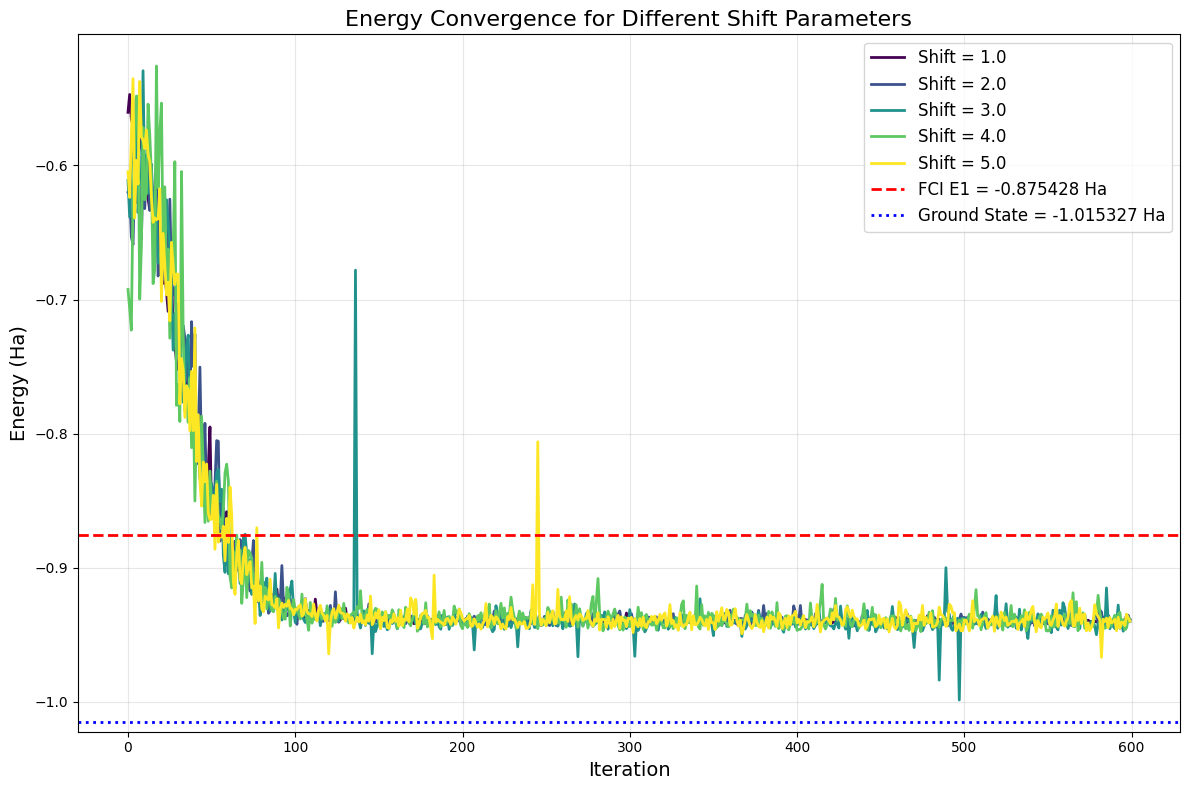

In [6]:
# Plot convergence curves for all shift values
plt.figure(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(shift_values)))

for i, shift in enumerate(shift_values):
    r = results[shift]
    plt.plot(r['iterations'], r['energy_history'], 
             color=colors[i], linewidth=2, 
             label=f'Shift = {shift}')

# Add FCI reference line
plt.axhline(y=E_fcis[1], color='red', linestyle='--', linewidth=2, 
            label=f'FCI E1 = {E_fcis[1]:.6f} Ha')
plt.axhline(y=final_energy_gs, color='blue', linestyle=':', linewidth=2,
            label=f'Ground State = {final_energy_gs:.6f} Ha')

plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Energy (Ha)', fontsize=14)
plt.title('Energy Convergence for Different Shift Parameters', fontsize=16)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('shift_convergence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

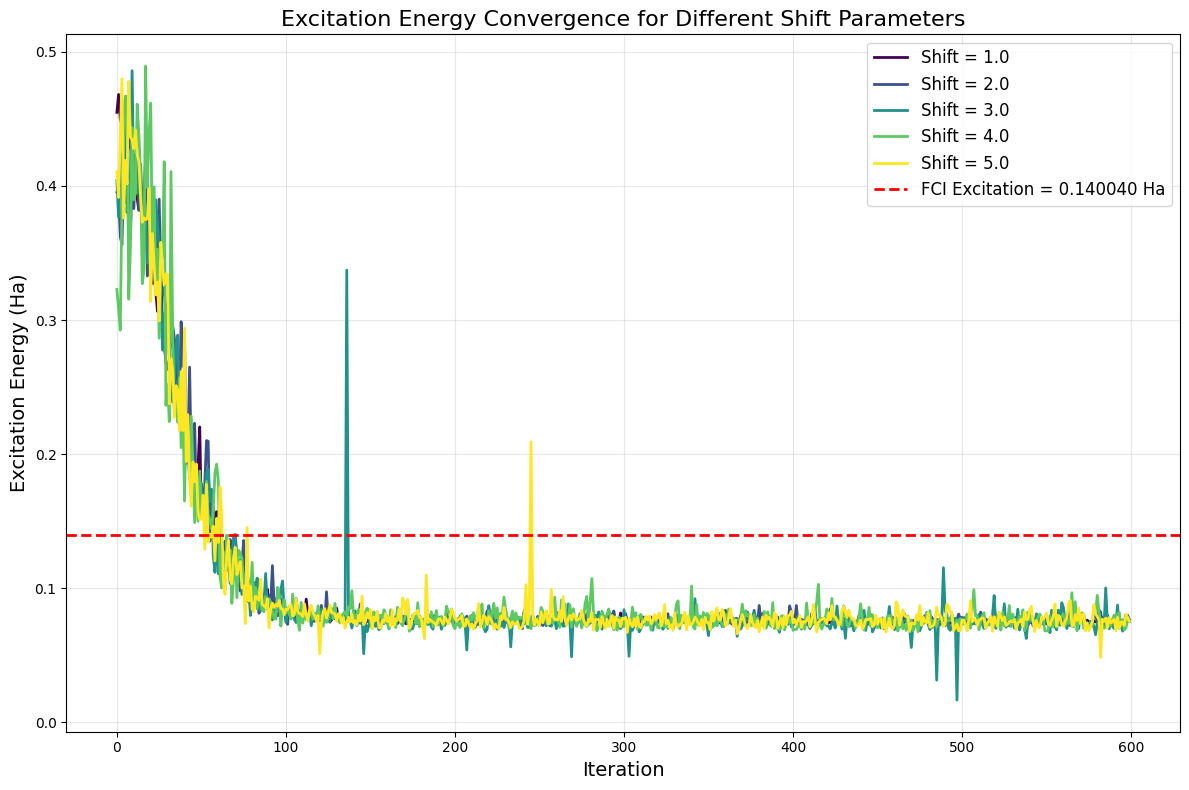

In [7]:
# Plot excitation energy convergence
plt.figure(figsize=(12, 8))

for i, shift in enumerate(shift_values):
    r = results[shift]
    excitation_history = [e - final_energy_gs for e in r['energy_history']]
    plt.plot(r['iterations'], excitation_history, 
             color=colors[i], linewidth=2, 
             label=f'Shift = {shift}')

# Add FCI reference line
fci_excitation = E_fcis[1] - E_fcis[0]
plt.axhline(y=fci_excitation, color='red', linestyle='--', linewidth=2, 
            label=f'FCI Excitation = {fci_excitation:.6f} Ha')

plt.xlabel('Iteration', fontsize=14)
plt.ylabel('Excitation Energy (Ha)', fontsize=14)
plt.title('Excitation Energy Convergence for Different Shift Parameters', fontsize=16)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('shift_excitation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

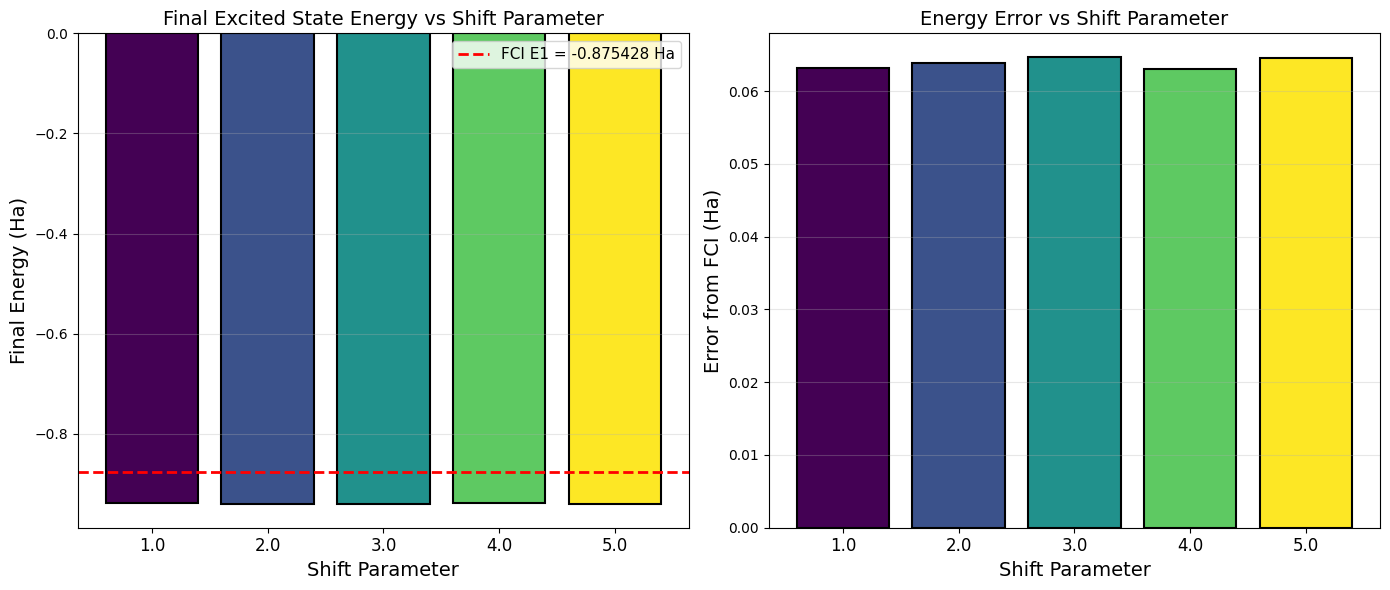

In [8]:
# Bar plot comparing final energies
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Final energy comparison
ax1 = axes[0]
final_energies = [results[s]['final_energy'] for s in shift_values]
bars1 = ax1.bar(range(len(shift_values)), final_energies, 
                color=colors, edgecolor='black', linewidth=1.5)
ax1.axhline(y=E_fcis[1], color='red', linestyle='--', linewidth=2, 
            label=f'FCI E1 = {E_fcis[1]:.6f} Ha')
ax1.set_xticks(range(len(shift_values)))
ax1.set_xticklabels([f'{s}' for s in shift_values], fontsize=12)
ax1.set_xlabel('Shift Parameter', fontsize=14)
ax1.set_ylabel('Final Energy (Ha)', fontsize=14)
ax1.set_title('Final Excited State Energy vs Shift Parameter', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Error comparison
ax2 = axes[1]
errors = [results[s]['error'] for s in shift_values]
bars2 = ax2.bar(range(len(shift_values)), errors, 
                color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(shift_values)))
ax2.set_xticklabels([f'{s}' for s in shift_values], fontsize=12)
ax2.set_xlabel('Shift Parameter', fontsize=14)
ax2.set_ylabel('Error from FCI (Ha)', fontsize=14)
ax2.set_title('Energy Error vs Shift Parameter', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('shift_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

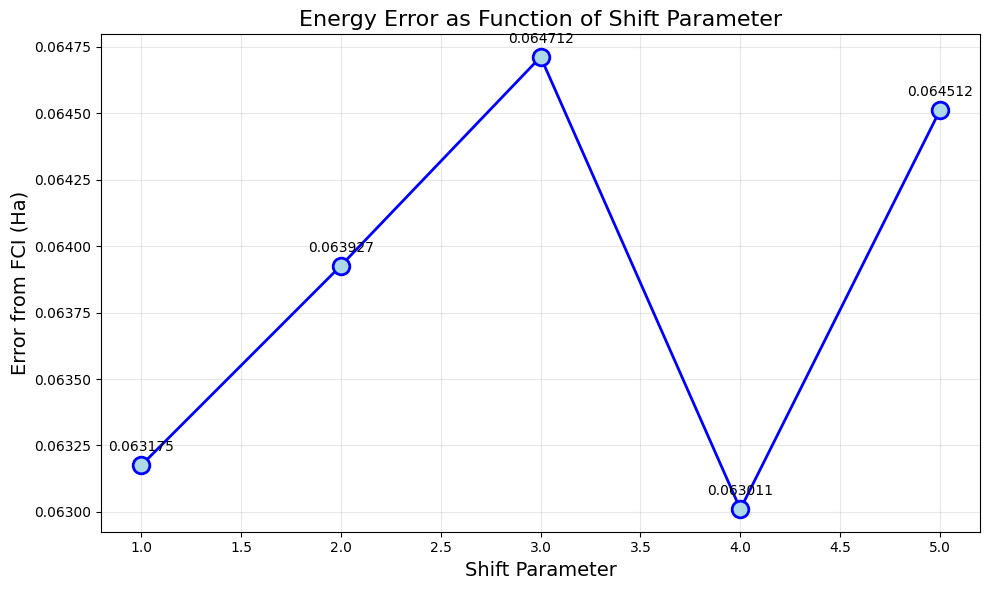

In [9]:
# Plot error as function of shift parameter
plt.figure(figsize=(10, 6))

errors = [results[s]['error'] for s in shift_values]
plt.plot(shift_values, errors, 'o-', markersize=12, linewidth=2, 
         color='blue', markerfacecolor='lightblue', markeredgewidth=2)

plt.xlabel('Shift Parameter', fontsize=14)
plt.ylabel('Error from FCI (Ha)', fontsize=14)
plt.title('Energy Error as Function of Shift Parameter', fontsize=16)
plt.grid(True, alpha=0.3)

# Add annotations
for i, (s, e) in enumerate(zip(shift_values, errors)):
    plt.annotate(f'{e:.6f}', (s, e), textcoords="offset points", 
                 xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('shift_error_trend.png', dpi=150, bbox_inches='tight')
plt.show()

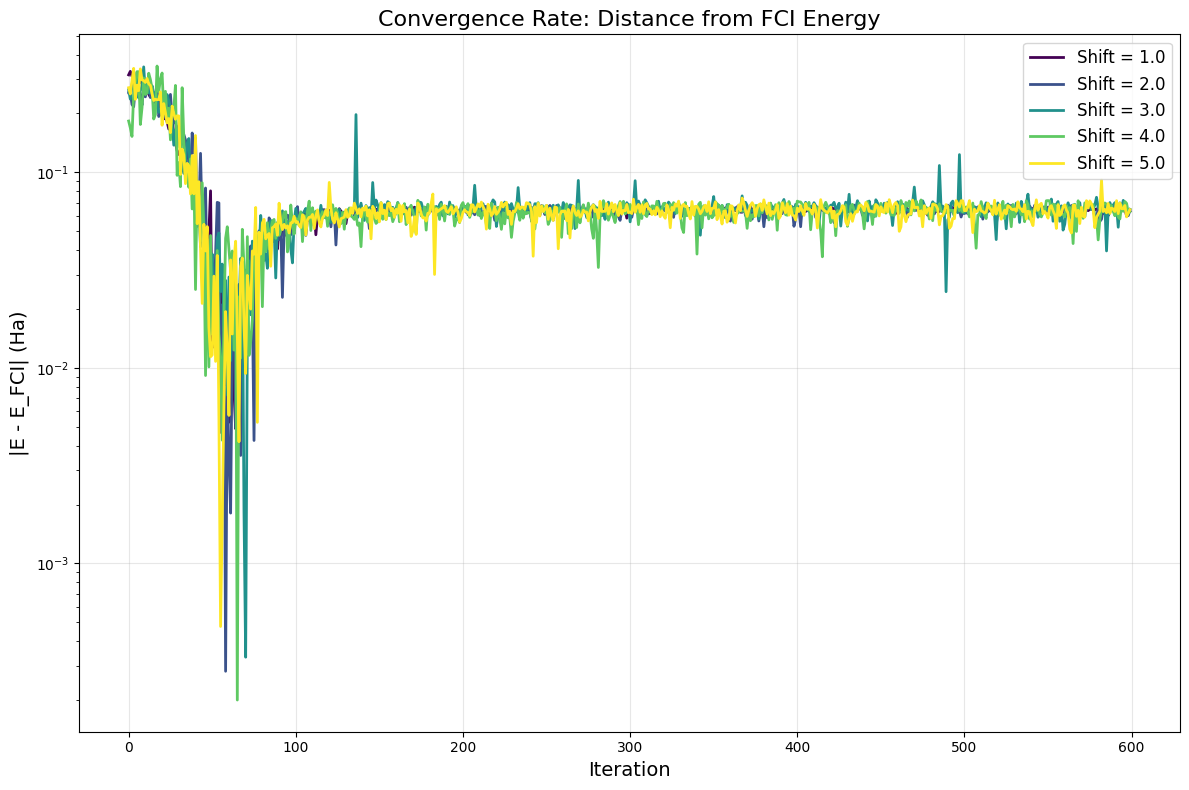

In [10]:
# Analyze convergence rate
plt.figure(figsize=(12, 8))

for i, shift in enumerate(shift_values):
    r = results[shift]
    energy = np.array(r['energy_history'])
    
    # Calculate distance from FCI
    distance = np.abs(energy - E_fcis[1])
    
    plt.semilogy(r['iterations'], distance, 
                 color=colors[i], linewidth=2, 
                 label=f'Shift = {shift}')

plt.xlabel('Iteration', fontsize=14)
plt.ylabel('|E - E_FCI| (Ha)', fontsize=14)
plt.title('Convergence Rate: Distance from FCI Energy', fontsize=16)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('shift_convergence_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

This study investigates the effect of the shift parameter on excited state calculations:

1. **Shift Parameter Role**: The shift parameter controls the strength of the orthogonality constraint between the excited state and ground state.

2. **Small Shift Values (1.0-2.0)**: May not provide sufficient orthogonality constraint, potentially leading to collapse to the ground state.

3. **Moderate Shift Values (3.0-4.0)**: Generally provide a good balance between orthogonality and energy optimization.

4. **Large Shift Values (5.0+)**: May overly constrain the optimization, potentially slowing convergence.

The optimal shift parameter depends on the specific system and should be determined through systematic testing.

In [11]:
# Save all results to a file
import pickle

with open('shift_study_results.pkl', 'wb') as f:
    pickle.dump({
        'shift_values': shift_values,
        'results': results,
        'fci_energies': E_fcis,
        'ground_state_energy': final_energy_gs,
        'parameters': {
            'n_iter': n_iter,
            'learning_rate': learning_rate
        }
    }, f)

print("Results saved to shift_study_results.pkl")

Results saved to shift_study_results.pkl
